# Importing Libraries

In [1]:
import sys
from pathlib import Path


sys.path.append(str(Path.cwd().parent))

from src.config import *

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.feature_selection import VarianceThreshold

from sklearn.model_selection import train_test_split

import joblib

import warnings
warnings.filterwarnings("ignore")

# Loading Dataset

In [2]:
df = pd.read_parquet(
    PROCESSED_DATA_DIR / "breast_cancer.parquet"
)

print(df.shape)

(151, 54676)


# Separating Features and Labels

In [3]:
TARGET_COL = "type"

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

print("Features:", X.shape)
print("Labels:", y.shape)

Features: (151, 54675)
Labels: (151,)


# Label Encoding

## Encode

In [4]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

## Inspect Mapping

In [5]:
label_mapping = dict(
    zip(
        label_encoder.classes_,
        range(len(label_encoder.classes_))
    )
)

print(label_mapping)

{'HER': 0, 'basal': 1, 'cell_line': 2, 'luminal_A': 3, 'luminal_B': 4, 'normal': 5}


## Saving Encoder

In [6]:
joblib.dump(
    label_encoder,
    ARTIFACT_DIR / "label_encoder.pkl"
)
print('Done')

Done


# Variance Thresholding

## Apply VarianceThreshold

In [7]:
thresholds = [0.001, 0.01, 0.1, 0.5, 1.0]

for t in thresholds:
    
    selector_temp = VarianceThreshold(threshold=t)
    
    X_temp = selector_temp.fit_transform(X)
    
    print(
        f"Threshold={t:<5} "
        f"Remaining genes={X_temp.shape[1]}"
    )

Threshold=0.001 Remaining genes=54675
Threshold=0.01  Remaining genes=54605
Threshold=0.1   Remaining genes=35192
Threshold=0.5   Remaining genes=11715
Threshold=1.0   Remaining genes=4432


In [10]:
variance_results = pd.DataFrame({
    "threshold": thresholds,
    "remaining_genes": [
        54675,
        54605,
        35192,
        11715,
        4432
    ]
})

variance_results

,threshold,remaining_genes
0,0.001,54675
1,0.010,54605
2,0.100,35192
3,0.500,11715
4,1.000,4432


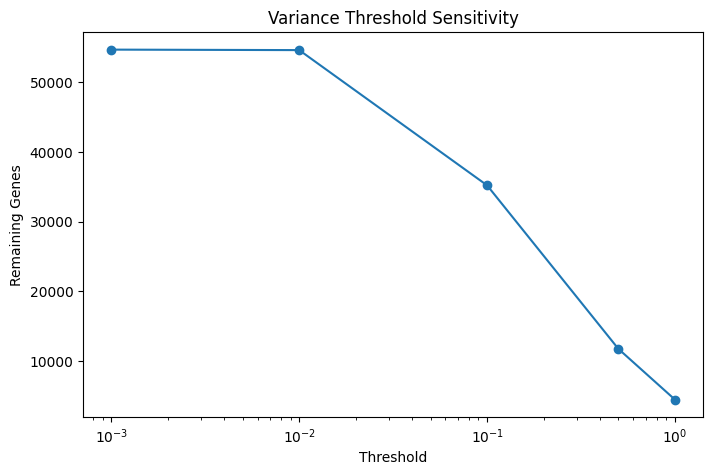

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    variance_results["threshold"],
    variance_results["remaining_genes"],
    marker="o"
)

plt.xscale("log")

plt.title("Variance Threshold Sensitivity")
plt.xlabel("Threshold")
plt.ylabel("Remaining Genes")

plt.show()

In [12]:
selector = VarianceThreshold(
    threshold=0.1
)

X_var = selector.fit_transform(X)

### Compare Shapes

In [13]:
print("Original shape:", X.shape)
print("After variance filtering:", X_var.shape)

Original shape: (151, 54675)
After variance filtering: (151, 35192)


## Recovering Selected Gene Names

In [14]:
selected_features = X.columns[
    selector.get_support()
]

print("Selected genes:", len(selected_features))

Selected genes: 35192


# Saving Feature List

In [15]:
joblib.dump(
    selected_features,
    ARTIFACT_DIR / "selected_features.pkl"
)

['C:\\Jupyter Notebook\\PROJECTS\\Breast_cancer_analysis\\data\\artifacts\\selected_features.pkl']

# Saving Selector

In [16]:
joblib.dump(
    selector,
    ARTIFACT_DIR / "variance_selector.pkl"
)
print('Done')

Done


# Train-Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_var,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

# Standard Scaling

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Saving Scaler

In [19]:
joblib.dump(
    scaler,
    ARTIFACT_DIR / "standard_scaler.pkl"
)

['C:\\Jupyter Notebook\\PROJECTS\\Breast_cancer_analysis\\data\\artifacts\\standard_scaler.pkl']

## Saving Processed Arrays

In [20]:
joblib.dump(
    X_train_scaled,
    ARTIFACT_DIR / "X_train_scaled.pkl"
)

joblib.dump(
    X_test_scaled,
    ARTIFACT_DIR / "X_test_scaled.pkl"
)

joblib.dump(
    y_train,
    ARTIFACT_DIR / "y_train.pkl"
)

joblib.dump(
    y_test,
    ARTIFACT_DIR / "y_test.pkl"
)
print('Done')

Done


## Saving Metadata

In [21]:
metadata = {
    "original_features": X.shape[1],
    "selected_features": len(selected_features),
    "train_samples": X_train.shape[0],
    "test_samples": X_test.shape[0],
    "num_classes": len(label_mapping)
}

joblib.dump(
    metadata,
    ARTIFACT_DIR / "metadata.pkl"
)

metadata

{'original_features': 54675,
 'selected_features': 35192,
 'train_samples': 120,
 'test_samples': 31,
 'num_classes': 6}